In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [ ]:
train = pd.read_csv('train_spooky.csv')

In [24]:
train.head()

,id,text,author
0,id26305,"This process, however, afforded me no means of...",EAP
1,id17569,It never once occurred to me that the fumbling...,HPL
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP
3,id27763,How lovely is spring As we looked from Windsor...,MWS
4,id12958,"Finding nothing else, not even gold, the Super...",HPL


In [25]:
train.shape, test.shape

((19579, 3), (8392, 2))

In [26]:
train['text_clean']= train['text'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True).str.lower()
train['text_clean'].head()

0    this process however afforded me no means of a...
1    it never once occurred to me that the fumbling...
2    in his left hand was a gold snuff box from whi...
3    how lovely is spring as we looked from windsor...
4    finding nothing else not even gold the superin...
Name: text_clean, dtype: object

In [27]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop = stopwords.words('english')
train['text_clean'] = train['text_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop]))
train['text_clean'].head()  

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    process however afforded means ascertaining di...
1           never occurred fumbling might mere mistake
2    left hand gold snuff box capered hill cutting ...
3    lovely spring looked windsor terrace sixteen f...
4    finding nothing else even gold superintendent ...
Name: text_clean, dtype: object

In [28]:
nltk.download('punkt')
from nltk.tokenize import word_tokenize
train['text_clean'] = train['text_clean'].apply(word_tokenize)
train['text_clean'].head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


0    [process, however, afforded, means, ascertaini...
1    [never, occurred, fumbling, might, mere, mistake]
2    [left, hand, gold, snuff, box, capered, hill, ...
3    [lovely, spring, looked, windsor, terrace, six...
4    [finding, nothing, else, even, gold, superinte...
Name: text_clean, dtype: object

In [29]:
freq = nltk.FreqDist(word for word in train['text_clean'].sum())
freq

FreqDist({'one': 1614, 'upon': 1411, 'could': 1316, 'would': 1241, 'man': 730, 'time': 729, 'yet': 715, 'said': 704, 'even': 701, 'might': 629, ...})

In [30]:
import re
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
train['text_clean'] = train['text_clean'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
train['text_clean'].head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...


0    [process, however, afforded, mean, ascertainin...
1    [never, occurred, fumbling, might, mere, mistake]
2    [left, hand, gold, snuff, box, capered, hill, ...
3    [lovely, spring, looked, windsor, terrace, six...
4    [finding, nothing, else, even, gold, superinte...
Name: text_clean, dtype: object

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

max_features = 1000
vectorizer = CountVectorizer(max_features=max_features, stop_words='english')
train_vectorized = vectorizer.fit_transform(train['text_clean'].apply(lambda x: ' '.join(x))).toarray()
train_vectorized.shape

(19579, 1000)

In [32]:
all_features = vectorizer.get_feature_names_out()
all_features[:10]

array(['able', 'abode', 'absence', 'abyss', 'accident', 'account', 'act',
       'action', 'actually', 'added'], dtype=object)

In [37]:
x = train_vectorized
y = train['author']

In [40]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [42]:
x_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [43]:
y

0        EAP
1        HPL
2        EAP
3        MWS
4        HPL
        ... 
19574    EAP
19575    EAP
19576    EAP
19577    EAP
19578    HPL
Name: author, Length: 19579, dtype: object

In [50]:
from sklearn.metrics import confusion_matrix


def confusion(ytest,y_pred):
    names= ['EAP', 'HPL', 'MWS']
    cm = confusion_matrix(ytest, y_pred, labels=names)
    f,ax=plt.subplots(figsize=(5,5))
    sns.heatmap(cm,annot=True,linewidth=.5,linecolor="r",fmt=".0f",ax=ax)
    plt.xlabel("y_pred")
    plt.ylabel("y_true")
    ax.set_xticklabels(names)
    ax.set_yticklabels(names)
    plt.show()

    return

In [51]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train,y_train)
print("acc : ", nb.score(x_test,y_test))

acc :  0.6381511746680286


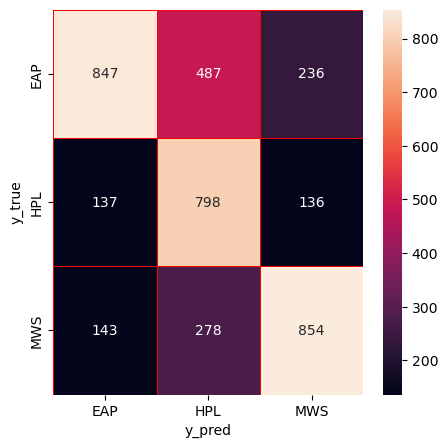

In [52]:
y_pred = nb.predict(x_test)
confusion(y_test, y_pred)

In [53]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
print("acc : ", rf.score(x_test, y_test))

acc :  0.6325331971399387


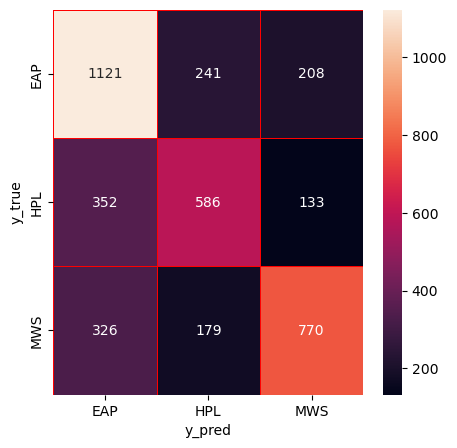

In [56]:
y_pred = rf.predict(x_test)
confusion(y_test, y_pred)

In [57]:
importance = rf.feature_importances_
all_features = vectorizer.get_feature_names_out()
columns = all_features

indices = np.argsort(importance)[::-1][:10]
selected_features = [columns[i] for i in indices]
selected_importances = importance[indices]

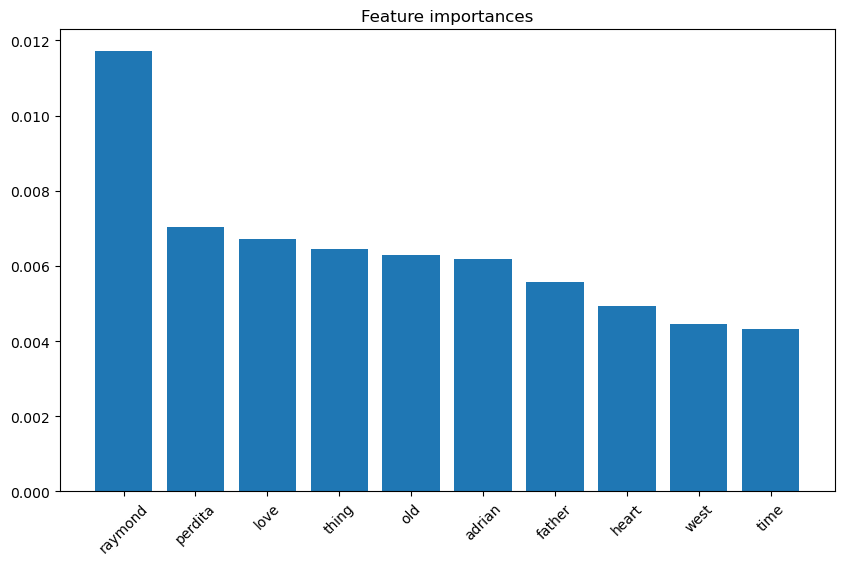

In [58]:
plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.bar(selected_features, selected_importances, align="center")
plt.xticks(rotation=45)
plt.show()

In [59]:
from sklearn.svm import LinearSVC

svm = LinearSVC(random_state=42)
svm.fit(x_train, y_train)
print("acc : ", svm.score(x_test, y_test))


acc :  0.7012257405515833


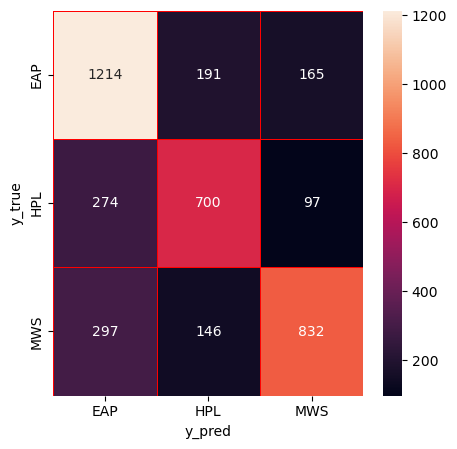

In [61]:
y_pred = svm.predict(x_test)
confusion(y_test, y_pred)